In [1]:
import tqdm
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import scipy
import seaborn as sns

In [2]:
%load_ext autoreload
%autoreload 2
import speed_plotting_helpers

In [3]:
activities = pd.read_csv("../../../output/ChopTFs_pipeline/speed/activities_to_fit.csv", index_col = 0)
activities

,ADseq,time,activity,ci_low,ci_hi,class,mean_diff,pval_fdr,error,activity_norm,ci_low_norm,ci_hi_norm
142,AAKRSGAKTIIFPKDNLNDWEELPDNVKEGLEPLAADWYN,0,-0.402631,-0.569555,-0.165864,ns,NaN,NaN,0.102982,0.000000,-0.166925,0.236767
143,AAKRSGAKTIIFPKDNLNDWEELPDNVKEGLEPLAADWYN,2,0.067719,-0.086268,0.196101,ns,0.470349,0.009113,0.072033,0.470349,0.316362,0.598732
144,AAKRSGAKTIIFPKDNLNDWEELPDNVKEGLEPLAADWYN,10,0.423909,0.019486,0.796737,activator,0.826539,0.001168,0.198278,0.826539,0.422117,1.199367
145,AAKRSGAKTIIFPKDNLNDWEELPDNVKEGLEPLAADWYN,15,0.786642,0.691610,0.871152,activator,1.189273,0.000881,0.045801,1.189273,1.094241,1.273783
146,AAKRSGAKTIIFPKDNLNDWEELPDNVKEGLEPLAADWYN,20,0.567249,0.388742,0.736468,activator,0.969880,0.000730,0.088706,0.969880,0.791373,1.139099
...,...,...,...,...,...,...,...,...,...,...,...,...
118600,YVPTRNTFNYDVKISNDFFDNGDNLYGNDEEVLFYEDNYN,20,1.560700,1.399946,1.635293,activator,1.430020,0.000730,0.060037,1.430020,1.269266,1.504612
118601,YVPTRNTFNYDVKISNDFFDNGDNLYGNDEEVLFYEDNYN,30,1.707046,1.668821,1.736109,activator,1.576366,0.000621,0.017165,1.576366,1.538140,1.605428
118602,YVPTRNTFNYDVKISNDFFDNGDNLYGNDEEVLFYEDNYN,40,1.721909,1.702173,1.740391,activator,1.591228,0.000550,0.009749,1.591228,1.571493,1.609710
118603,YVPTRNTFNYDVKISNDFFDNGDNLYGNDEEVLFYEDNYN,50,1.650853,1.592250,1.699947,activator,1.520173,0.000548,0.027474,1.520173,1.461570,1.569266


In [4]:
import numpy as np
from scipy.optimize import curve_fit

def make_feasible(p0, lb, ub):
    eps = 1e-6
    return np.minimum(np.maximum(p0, np.array(lb) + eps), np.array(ub) - eps)
    
def hill(t, Vmax, K, n):
    return Vmax * (t**n) / (K**n + t**n)

def weighted_r2(y, y_pred, sigma):
    w = 1 / np.clip(sigma, 1e-6, None)**2
    y_wmean = np.sum(w * y) / np.sum(w)

    ss_res = np.sum(w * (y - y_pred)**2)
    ss_tot = np.sum(w * (y - y_wmean)**2)

    return 1 - ss_res / ss_tot if ss_tot > 0 else np.nan


def compute_t_half_obs(t, popt, obs_max):
    # dense grid for smooth interpolation
    t_grid = np.linspace(np.min(t), np.max(t), 500)
    y_fit = hill(t_grid, *popt)

    target = 0.5 * obs_max

    # find closest point
    idx = np.argmin(np.abs(y_fit - target))
    return t_grid[idx]


def fit_hill(df):
    df = df.sort_values("time")

    t = df["time"].values.astype(float)
    y = df["activity_norm"].values.astype(float)
    sigma = df["error"].values.astype(float)
    sigma = np.clip(sigma, 1e-6, None)

    # initial guesses
    lb = [0, 0, 0.5]
    ub = [np.max(y) * 3, np.max(t)*10 if np.max(t) > 0 else 10, 5]
    
    # initial guesses
    Vmax0 = np.max(y)
    K0 = np.median(t[t > 0]) if np.any(t > 0) else 1.0
    n0 = 2.0
    
    p0 = [Vmax0, K0, n0]
    p0 = make_feasible(p0, lb, ub)

    try:
        popt, pcov = curve_fit(
            hill,
            t,
            y,
            p0=p0,
            sigma=sigma,
            absolute_sigma=True,
            bounds=(lb, ub)
        )

        y_pred = hill(t, *popt)
        r2 = weighted_r2(y, y_pred, sigma)

        # model-derived max (was np.max(y))
        t_grid = np.linspace(np.min(t), np.max(t), 500)
        obs_max = np.max(hill(t_grid, *popt))

        t_half_obs = compute_t_half_obs(t, popt, obs_max)

        return {
            "Vmax": popt[0],
            "K_fit": popt[1],
            "n": popt[2],
            "r2": r2,
            "obs_max": obs_max,
            "t_half_obs": t_half_obs,
            "success": True
        }

    except RuntimeError:
        return {
            "Vmax": np.nan,
            "K_fit": np.nan,
            "n": np.nan,
            "r2": np.nan,
            "obs_max": np.nan,
            "t_half_obs": np.nan,
            "success": False
        }

In [5]:
results = []

for ad, subdf in tqdm.tqdm(activities.groupby("ADseq")):
    fit = fit_hill(subdf)
    fit["ADseq"] = ad
    results.append(fit)

results_df = pd.DataFrame(results)
results_df

100%|██████████| 857/857 [00:04<00:00, 192.00it/s]


,Vmax,K_fit,n,r2,obs_max,t_half_obs,success,ADseq
0,1.149810,2.356631,2.254018,0.953802,1.149031,2.404810,True,AAKRSGAKTIIFPKDNLNDWEELPDNVKEGLEPLAADWYN
1,1.565202,5.865398,2.039964,0.989576,1.551690,5.771543,True,AASNSYAIPENELLDEDTMNFISSLKNDLSNISNSLPFEY
2,1.417680,6.433799,1.954192,0.994926,1.399850,6.372745,True,AAVPQQNIAPPFLNTNSSATDSNPNTNLEDSLFFDHDLLS
3,0.953037,8.451622,2.661745,0.983502,0.947896,8.416834,True,AELHNWEPPLYDSVGNHNHAGTMESHPHTNIHEELKEFLS
4,1.382777,6.881619,2.761623,0.987302,1.379290,6.853707,True,AELPRRFMDLESWRIETYNELERWFQVDVPKNFEMMNCKF
...,...,...,...,...,...,...,...,...
852,1.432623,8.899621,2.315781,0.988815,1.415576,8.777555,True,YNFQNARLLIRKIWQNEADGISEHDLVHMIDELDYNINFA
853,0.988638,10.271602,2.247595,0.989637,0.970270,10.100200,True,YPQDLVSSPAMSHLTANNDDFDDLLSVASMNSNYLLPVNS
854,1.493279,7.455342,2.060709,0.983583,1.473238,7.334669,True,YSLVTGKQPLIPHEMTSCLFPKDVVGLGVDDSMDCFTLIN
855,1.166739,9.854011,2.090636,0.977233,1.140620,9.619238,True,YSNARGSDPSSYAIEGEYKTLATDDLGNILNLNYGETNEV


In [6]:
ok = results_df[results_df["r2"] >= 0.7]
print(f"Keeping {len(ok)} / {len(results_df)} sequences ({100*len(ok)/len(results_df):.1f}%)")

Keeping 855 / 857 sequences (99.8%)


In [7]:
ok.to_csv("/global/scratch/projects/fc_mvslab/OpenProjects/Sanjana/TREBL/output/ChopTFs_pipeline/speed/hill_fit_baseline_norm.csv")

In [8]:
not_ok = results_df[results_df["r2"] < 0.7]
not_ok

,Vmax,K_fit,n,r2,obs_max,t_half_obs,success,ADseq
18,2.420289,362.295437,0.560623,0.575740,0.647086,12.865731,True,ALDRKSSKKLLPLKYFLEQDELIFCLCLEYFERSLFSTMY
314,0.896591,4.108483,0.500000,0.573345,0.710634,1.803607,True,ILNEYNMNFNDNLGTSTSGKNKSACPSSFDANAMTKINPS


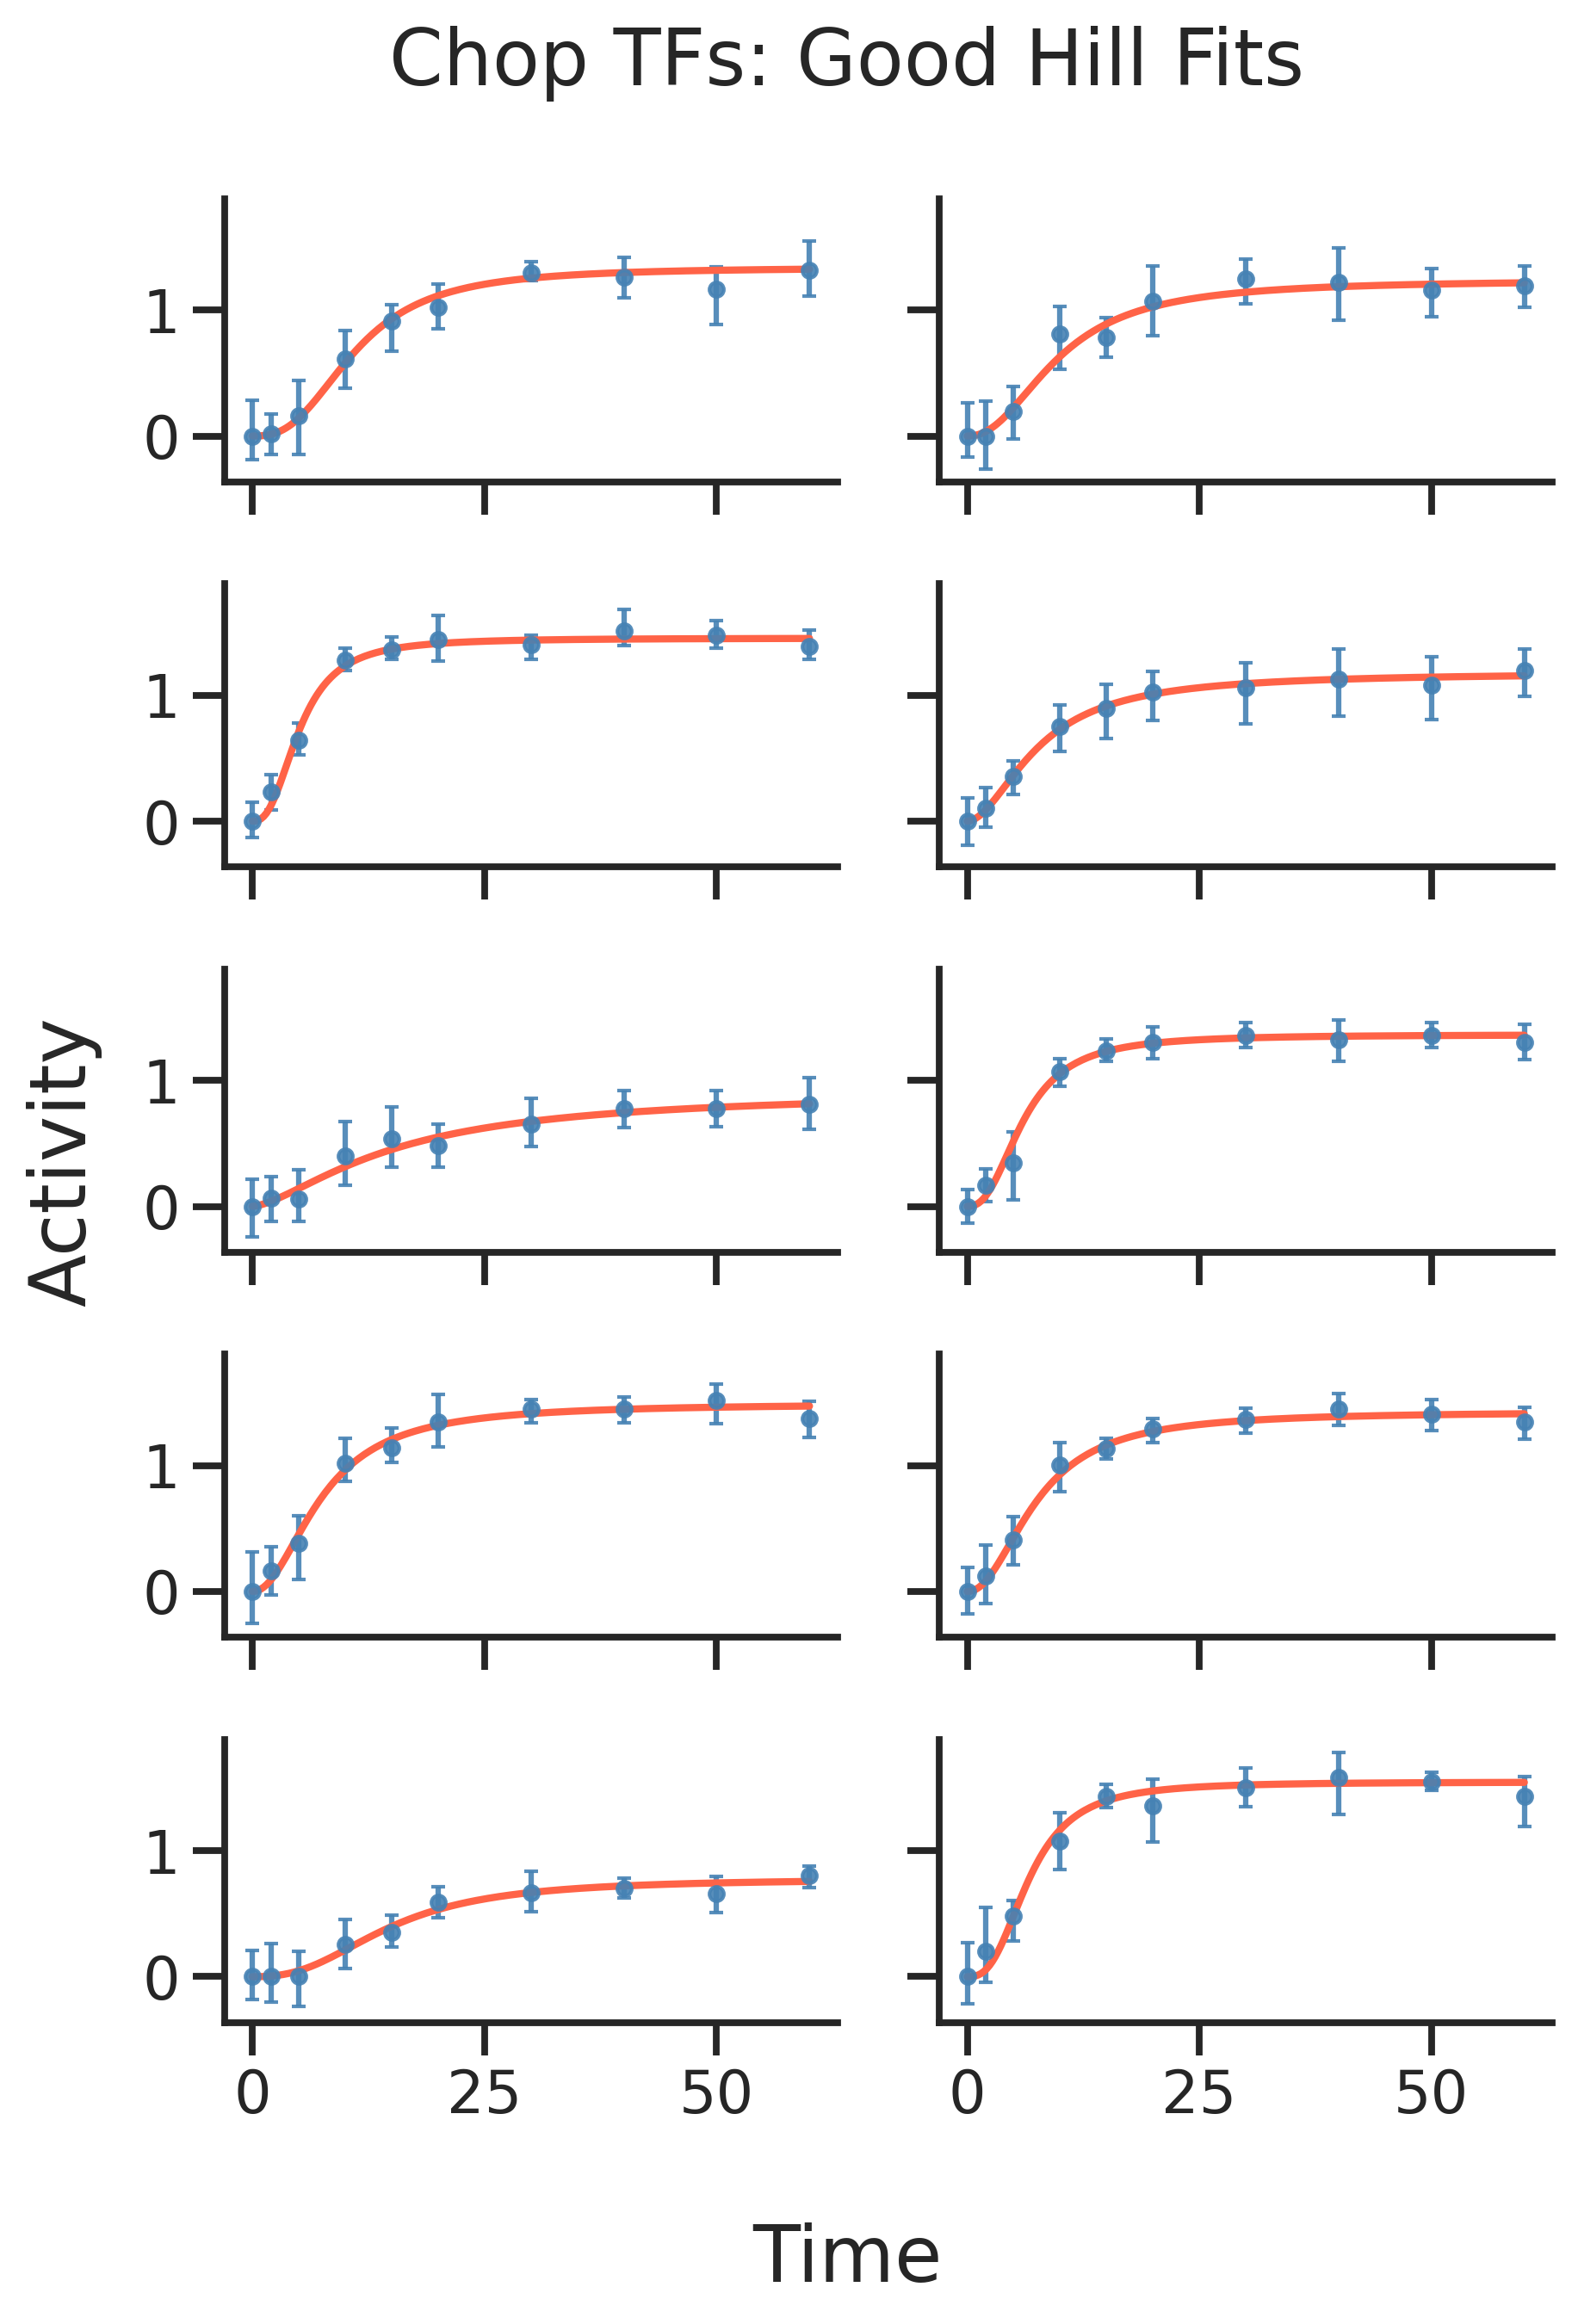

In [10]:
for df, title in zip([ok], ["Good"]):
    sample_adseqs = df.sample(16, random_state=44)['ADseq'].values

    speed_plotting_helpers.plot_model_fits(
        activities=activities,
        fit_results=results_df,
        sample_adseqs=sample_adseqs,
        model_fn=hill,
        model_params=['Vmax', 'K_fit', 'n'],
        y_col='activity_norm',
        ci_low_col='ci_low_norm',
        ci_hi_col='ci_hi_norm',
        title=f'Chop TFs: {title} Hill Fits',
    )

Pearson r = -0.581, p = 2.7e-78
Spearman rho = -0.624, p = 1.83e-93


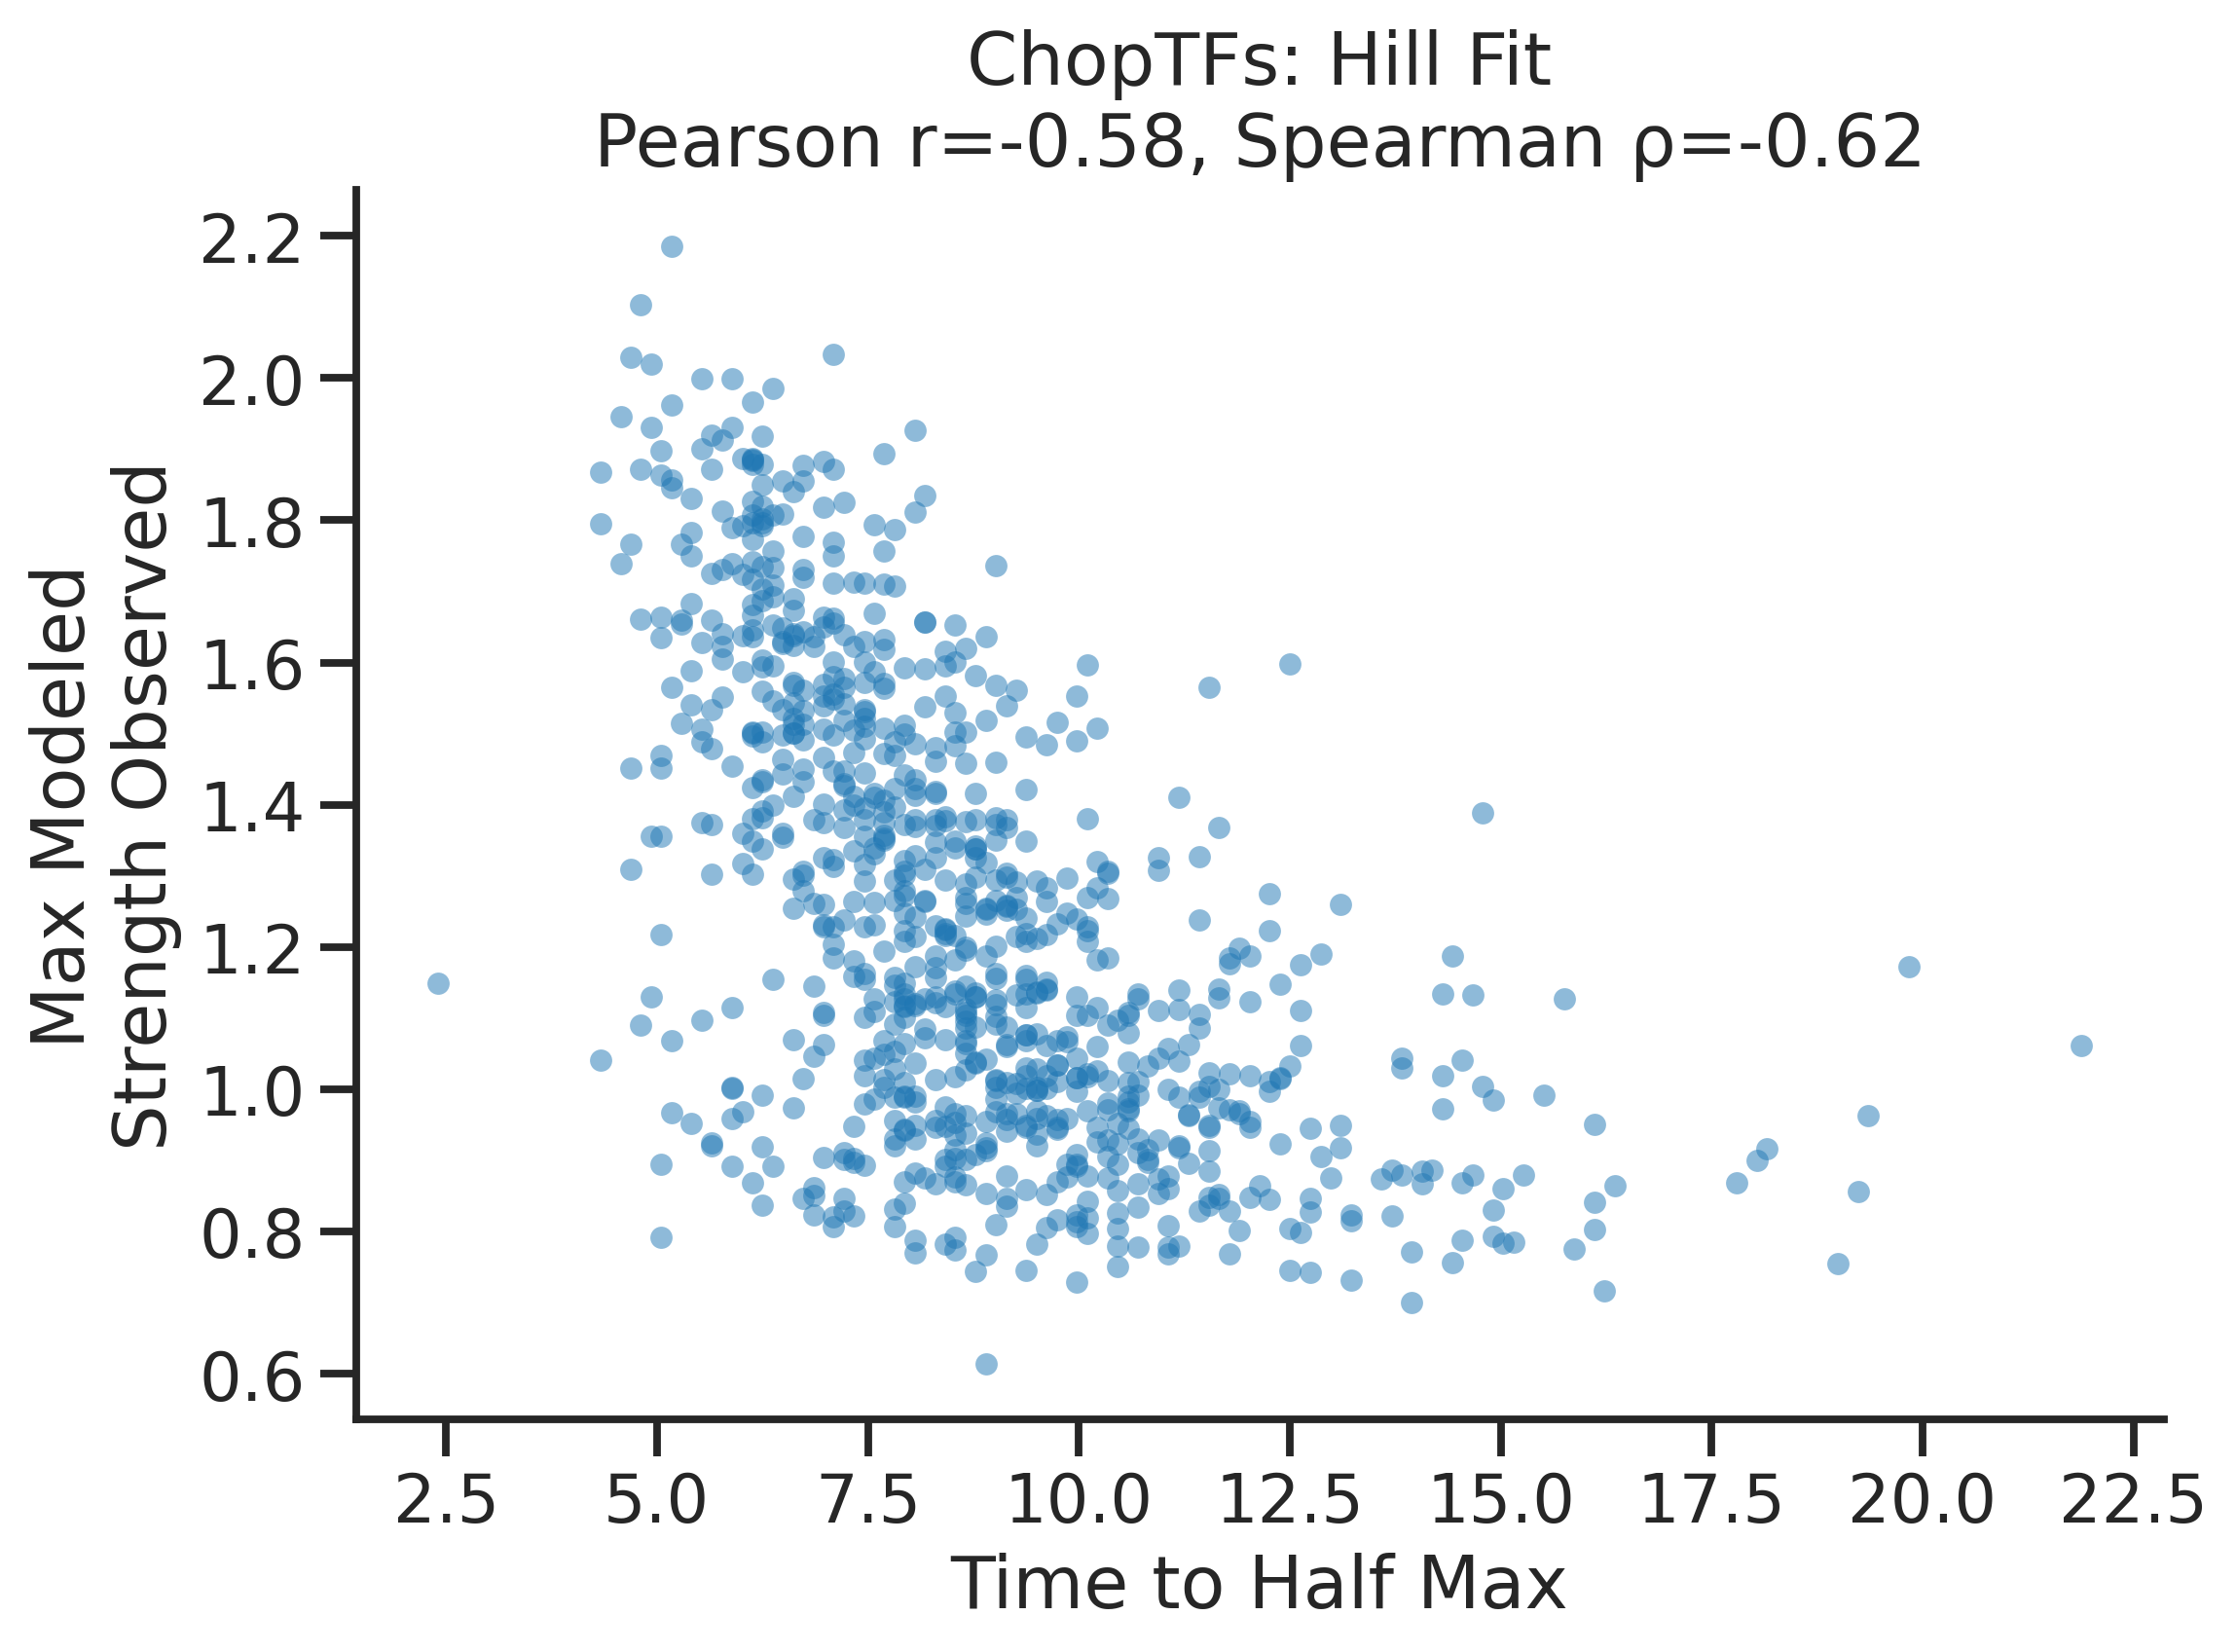

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr

sns.set_context('talk')

# --- calculate correlations ---
pearson_corr, pearson_p = pearsonr(ok['t_half_obs'], ok ['obs_max'])
spearman_corr, spearman_p = spearmanr(ok['t_half_obs'], ok ['obs_max'])

print(f"Pearson r = {pearson_corr:.3f}, p = {pearson_p:.3g}")
print(f"Spearman rho = {spearman_corr:.3f}, p = {spearman_p:.3g}")

# --- plot ---
fig, ax = plt.subplots(figsize=(8, 6), dpi = 300)

sc = ax.scatter(
    ok['t_half_obs'], ok['obs_max'],
    alpha=0.5,
    s=30,
    linewidths=0
)


ax.set_xlabel('Time to Half Max')
ax.set_ylabel('Max Modeled\nStrength Observed')
ax.set_title(f'ChopTFs: Hill Fit\nPearson r={pearson_corr:.2f}, Spearman ρ={spearman_corr:.2f}')

# ax.set_xlim(0,31)
# ax.set_ylim(0,2.5)

plt.tight_layout()
sns.despine()
plt.show()

In [12]:
# --- filter valid sequences ---
filtered = ok[
    (ok['t_half_obs'] >= 0) &
    (ok['obs_max'] >= 0) 
].copy()

# --- 1. Similar strength (A), different speed (k) ---
A_target = filtered['obs_max'].median()
A_tol = filtered['obs_max'].std() * 0.5

similar_A = filtered[(filtered['obs_max'] >= A_target - A_tol) &
                     (filtered['obs_max'] <= A_target + A_tol)].copy()
similar_A_sorted = similar_A.sort_values('t_half_obs')

if len(similar_A_sorted) >= 2:
    seq_simA_diffk = similar_A_sorted.iloc[[0,-1]]  # pick lowest and highest speed
else:
    seq_simA_diffk = similar_A_sorted.copy()  # fallback if not enough sequences

# --- 2. Similar speed (k), different strength (A) ---
k_target = filtered['t_half_obs'].median()
k_tol = filtered['t_half_obs'].std() * 0.2

similar_k = filtered[(filtered['t_half_obs'] >= k_target - k_tol) &
                     (filtered['t_half_obs'] <= k_target + k_tol)].copy()
similar_k_sorted = similar_k.sort_values('obs_max')

if len(similar_k_sorted) >= 2:
    seq_simk_diffA = similar_k_sorted.iloc[[0,-1]]  # pick lowest and highest strength
else:
    seq_simk_diffA = similar_k_sorted.copy()  # fallback

# --- combine sequences to plot ---
to_plot = pd.concat([seq_simA_diffk, seq_simk_diffA]).reset_index(drop=True)
to_plot

,Vmax,K_fit,n,r2,obs_max,t_half_obs,success,ADseq
0,1.149810,2.356631,2.254018,0.953802,1.149031,2.404810,True,AAKRSGAKTIIFPKDNLNDWEELPDNVKEGLEPLAADWYN
1,2.529053,83.241616,0.991812,0.922237,1.061002,21.883768,True,VKEVYNPEDLYHLRILNSLTACYLEYSISYGDIREQDDML
2,0.748348,12.888073,0.987429,0.955915,0.613906,8.897796,True,HHSITNFELVEDAPHQVGFSTPQMTAKQLMESVSELDLPP
3,1.969764,8.220786,1.911918,0.986396,1.926675,8.056112,True,DNSNNGDGNNNNTISELVCFDESIADLYPVEIDSPYLITL


Pearson r = -0.581, p = 2.7e-78
Spearman rho = -0.624, p = 1.83e-93


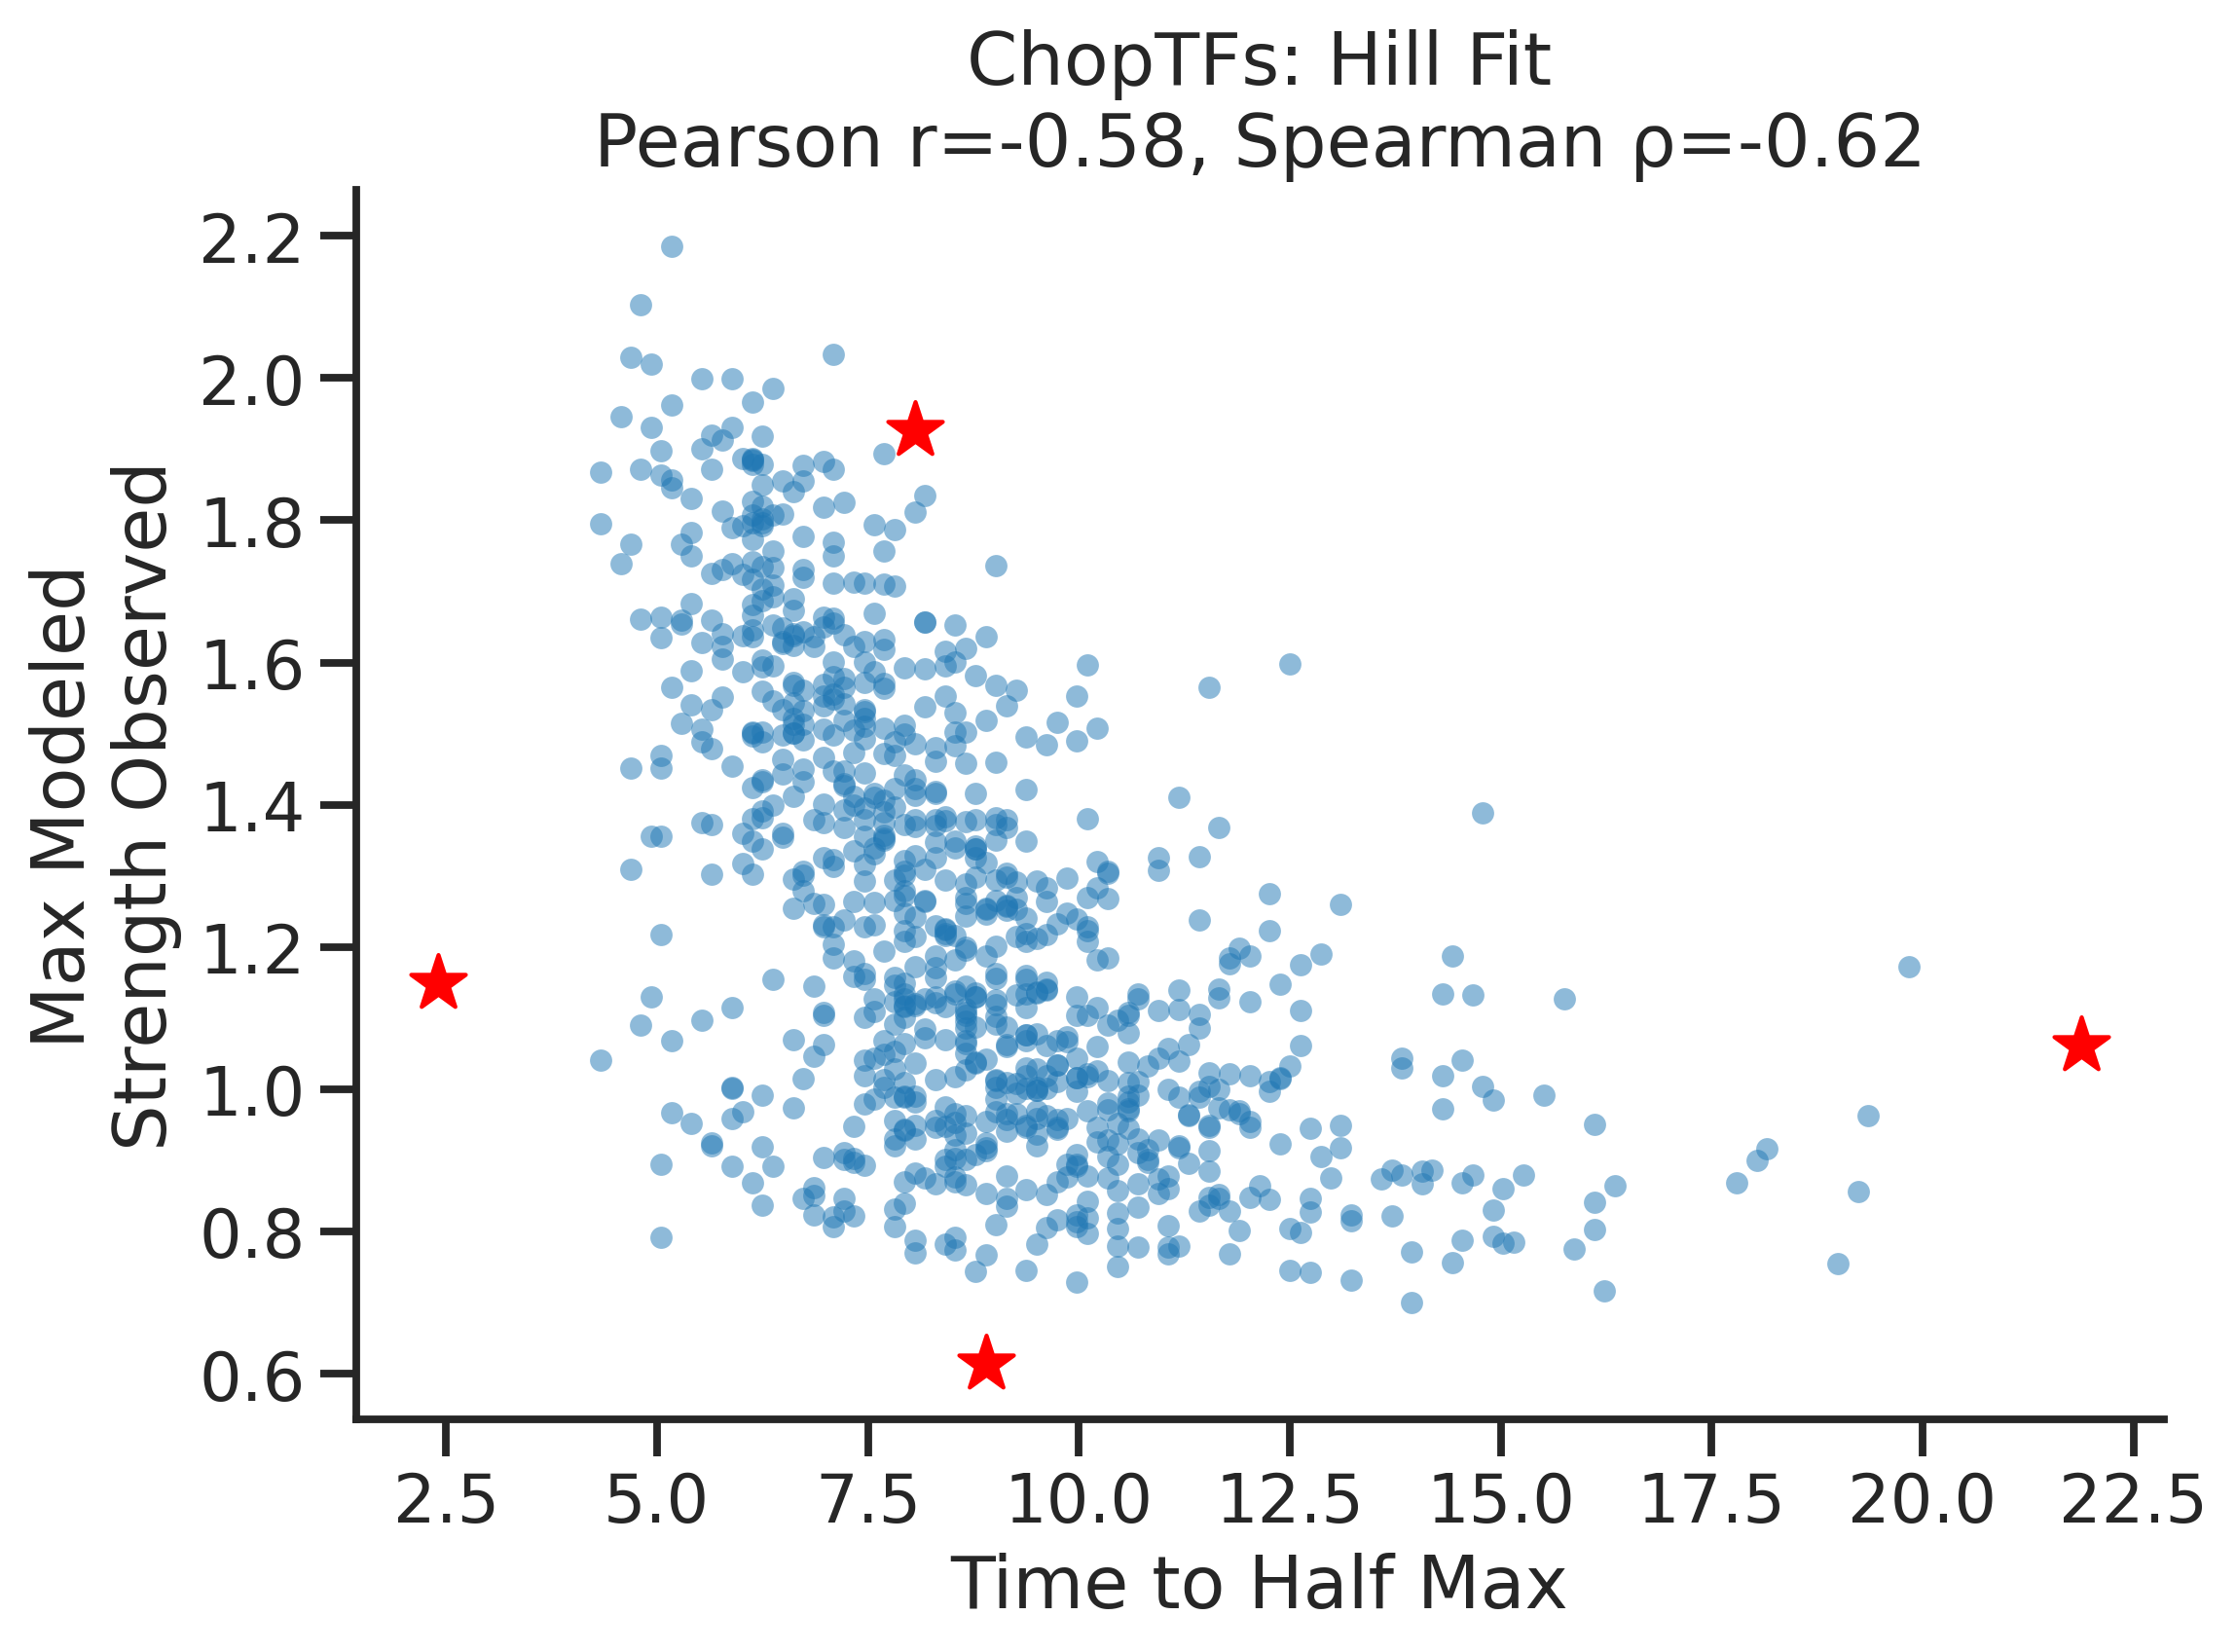

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr

sns.set_context('talk')

# --- calculate correlations ---
pearson_corr, pearson_p = pearsonr(ok['t_half_obs'], ok ['obs_max'])
spearman_corr, spearman_p = spearmanr(ok['t_half_obs'], ok ['obs_max'])

print(f"Pearson r = {pearson_corr:.3f}, p = {pearson_p:.3g}")
print(f"Spearman rho = {spearman_corr:.3f}, p = {spearman_p:.3g}")

# --- plot ---
fig, ax = plt.subplots(figsize=(8, 6), dpi = 300)

sc = ax.scatter(
    ok['t_half_obs'], ok['obs_max'],
    alpha=0.5,
    s=30,
    linewidths=0
)

ax.scatter(
    to_plot['t_half_obs'], to_plot['obs_max'],
    alpha=1,
    s=200,
    linewidths=1,
    edgecolors='red',
    color='red',
    marker = '*'
)

ax.set_xlabel('Time to Half Max')
ax.set_ylabel('Max Modeled\nStrength Observed')
ax.set_title(f'ChopTFs: Hill Fit\nPearson r={pearson_corr:.2f}, Spearman ρ={spearman_corr:.2f}')

# ax.set_xlim(0,31)
# ax.set_ylim(0,2.5)

plt.tight_layout()
sns.despine()
plt.show()

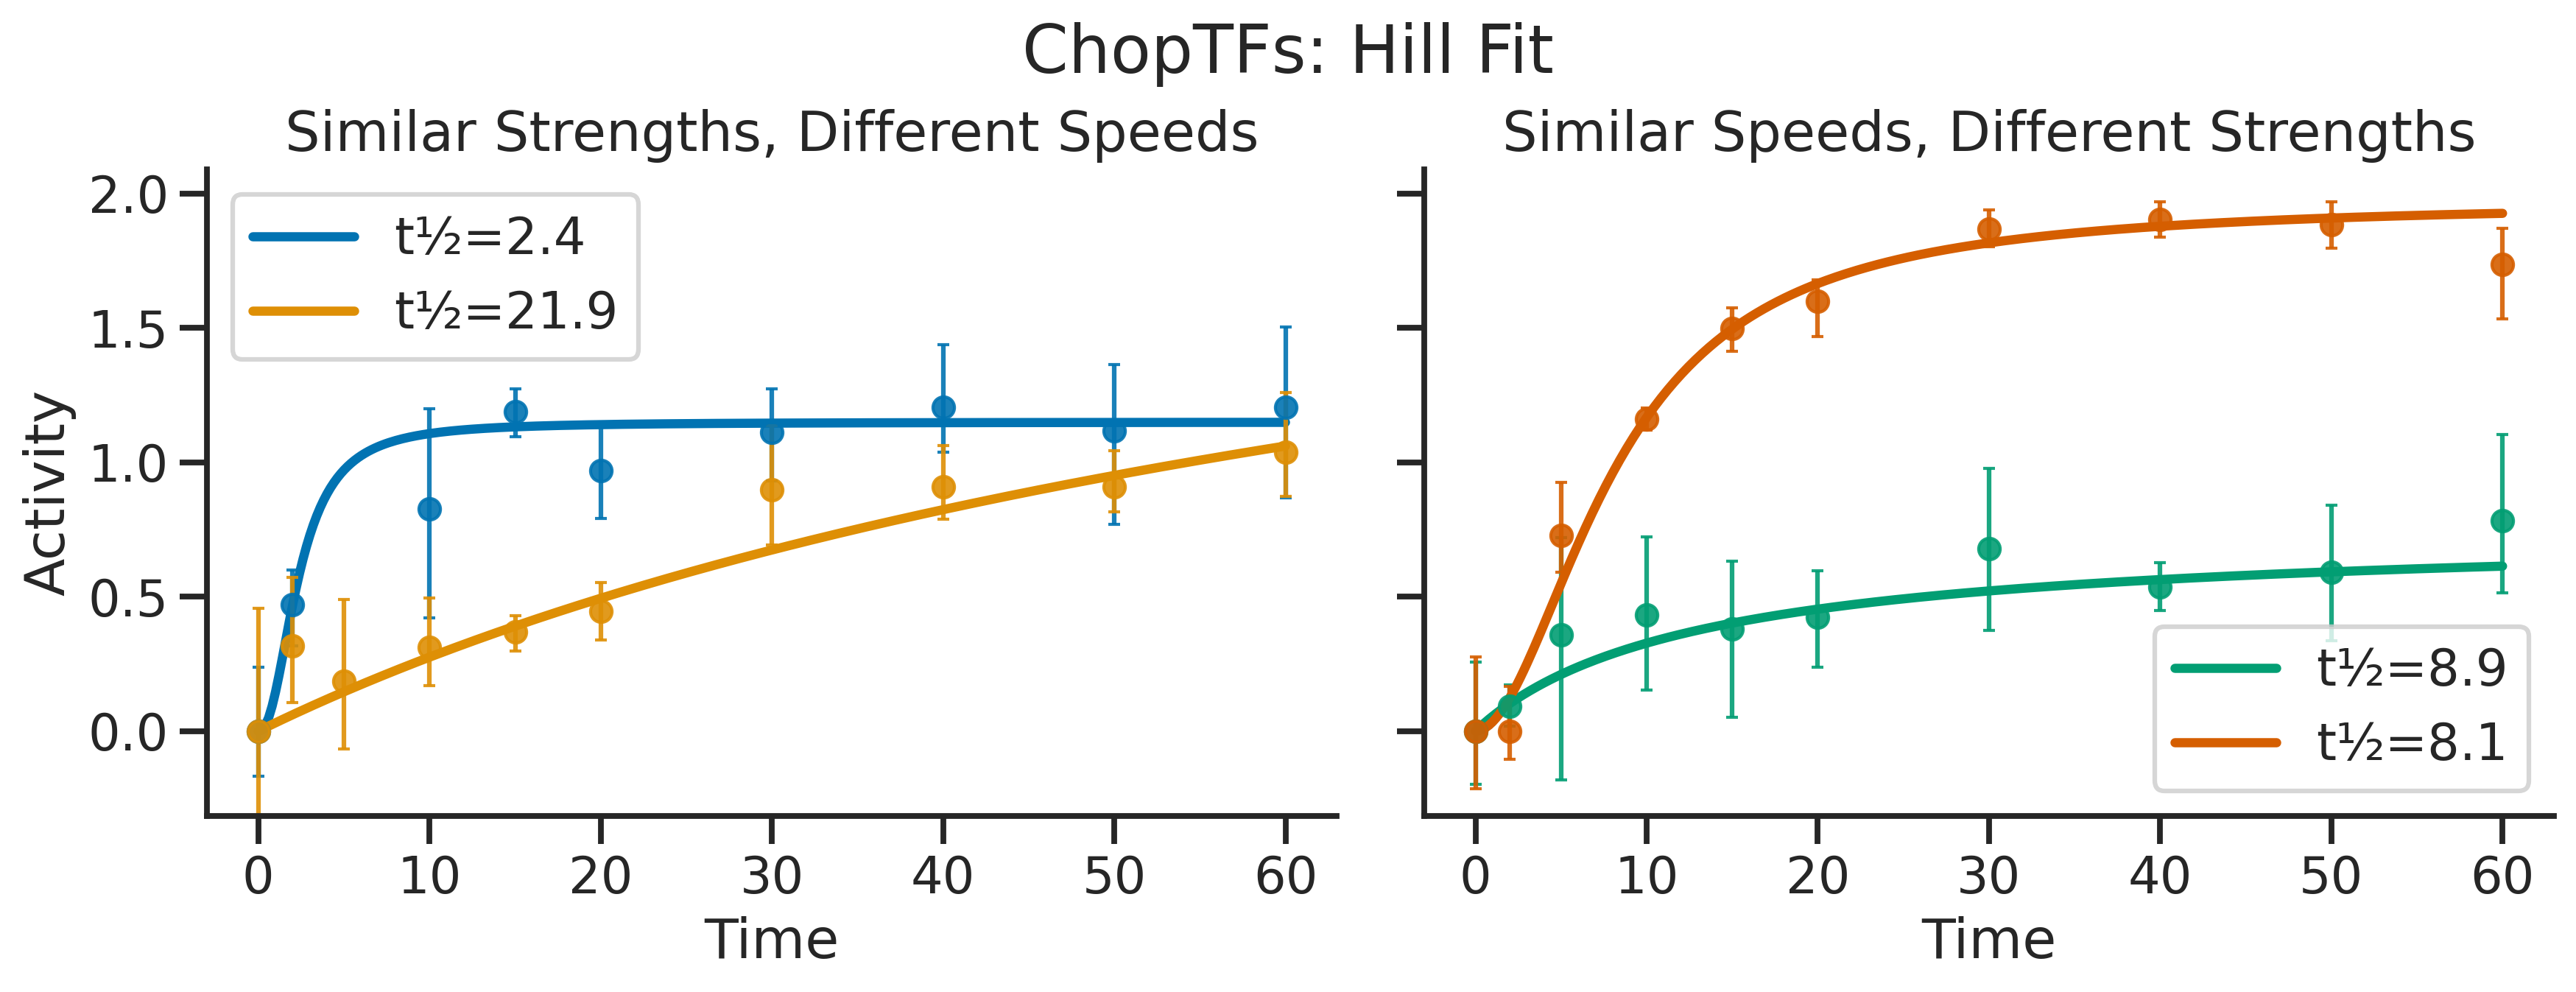

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_context('talk')

# --- Hill function ---
def hill(t, Vmax, K, n):
    return Vmax * (t**n) / (K**n + t**n)

t_fine = np.linspace(0, activities['time'].max(), 300)
colors = sns.color_palette('colorblind', n_colors=4)

fig, axs = plt.subplots(1, 2, figsize=(12, 5), sharey=True, dpi=300)

# -----------------------------
# Similar Strength, Different Speeds
# -----------------------------
for idx in [0, 1]:

    row = to_plot.iloc[idx]

    grp = activities[activities['ADseq'] == row['ADseq']].sort_values('time')
    t = grp['time'].values
    y = grp['activity_norm'].values

    # --- asymmetric CI error bars ---
    lower_err = y - grp['ci_low_norm'].values
    upper_err = grp['ci_hi_norm'].values - y

    lower_err = np.maximum(0, lower_err)
    upper_err = np.maximum(0, upper_err)

    axs[0].errorbar(
        t, y,
        yerr=[lower_err, upper_err],
        fmt='o',
        color=colors[idx],
        ecolor=colors[idx],
        elinewidth=1.5,
        capsize=2,
        markersize=7,
        alpha=0.9
    )

    if row['success'] and np.isfinite(row['Vmax']):
        axs[0].plot(
            t_fine,
            hill(t_fine, row['Vmax'], row['K_fit'], row['n']),
            color=colors[idx],
            linewidth=3,
            label=f"t½={row['t_half_obs']:.1f}"
        )

axs[0].set_xlabel('Time')
axs[0].set_ylabel('Activity')
axs[0].set_title("Similar Strengths, Different Speeds")
axs[0].legend()
sns.despine(ax=axs[0])

# -----------------------------
# Similar Speed, Different Strengths
# -----------------------------
for idx in [2, 3]:

    row = to_plot.iloc[idx]

    grp = activities[activities['ADseq'] == row['ADseq']].sort_values('time')
    t = grp['time'].values
    y = grp['activity_norm'].values

    # --- asymmetric CI error bars ---
    lower_err = y - grp['ci_low_norm'].values
    upper_err = grp['ci_hi_norm'].values - y

    lower_err = np.maximum(0, lower_err)
    upper_err = np.maximum(0, upper_err)

    axs[1].errorbar(
        t, y,
        yerr=[lower_err, upper_err],
        fmt='o',
        color=colors[idx],
        ecolor=colors[idx],
        elinewidth=1.5,
        capsize=2,
        markersize=7,
        alpha=0.9
    )

    if row['success'] and np.isfinite(row['Vmax']):
        axs[1].plot(
            t_fine,
            hill(t_fine, row['Vmax'], row['K_fit'], row['n']),
            color=colors[idx],
            linewidth=3,
            label=f"t½={row['t_half_obs']:.1f}"
        )

axs[1].set_xlabel('Time')
axs[1].set_title("Similar Speeds, Different Strengths")
axs[1].legend()
sns.despine(ax=axs[1])

# -----------------------------
# shared y-axis scaling
# -----------------------------
grps = activities[activities['ADseq'].isin(to_plot['ADseq'])]

y_min = (grps['activity_norm'] - (grps['ci_hi'] - grps['activity_norm'])).min()

for ax in axs:
    ax.set_ylim(bottom=y_min)

plt.suptitle("ChopTFs: Hill Fit", y=0.912)
plt.tight_layout()
plt.show()

# 